<a href="https://colab.research.google.com/github/RAJANGKR/SCT_ML_4/blob/main/SCT_ML_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rajangarudkar","key":"72f94091a830494eeea2fe011544ea71"}'}

In [2]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d gti-upm/leapgestrecog
!unzip -q leapgestrecog.zip -d /content/hand_data

Dataset URL: https://www.kaggle.com/datasets/gti-upm/leapgestrecog
License(s): CC-BY-NC-SA-4.0
100% 2.13G/2.13G [00:25<00:00, 89.1MB/s]



In [4]:
import os
import shutil
import random
from pathlib import Path

random.seed(42)

SOURCE_DIR = Path("/content/hand_data/leapGestRecog")
OUTPUT_DIR = Path("/content/mini_hand_data")

MAX_CLASSES = 5
IMAGES_PER_CLASS = 250
TRAIN_SPLIT = 0.8

if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

(OUTPUT_DIR / "train").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "val").mkdir(parents=True, exist_ok=True)

class_map = {}

all_class_names = set()
for person_folder in SOURCE_DIR.iterdir():
    if person_folder.is_dir():
        for gesture_folder in person_folder.iterdir():
            if gesture_folder.is_dir():
                all_class_names.add(gesture_folder.name)

selected_classes = sorted(list(all_class_names))[:MAX_CLASSES]
print("Selected classes:", selected_classes)

for cls in selected_classes:
    class_map[cls] = []

for person_folder in SOURCE_DIR.iterdir():
    if person_folder.is_dir():
        for gesture_folder in person_folder.iterdir():
            if gesture_folder.is_dir() and gesture_folder.name in selected_classes:
                images = list(gesture_folder.glob("*.png"))
                class_map[gesture_folder.name].extend(images)

for cls in selected_classes:
    images = class_map[cls]
    random.shuffle(images)
    images = images[:IMAGES_PER_CLASS]

    split_idx = int(len(images) * TRAIN_SPLIT)
    train_imgs = images[:split_idx]
    val_imgs = images[split_idx:]

    train_cls_dir = OUTPUT_DIR / "train" / cls
    val_cls_dir = OUTPUT_DIR / "val" / cls
    train_cls_dir.mkdir(parents=True, exist_ok=True)
    val_cls_dir.mkdir(parents=True, exist_ok=True)

    for img_path in train_imgs:
        shutil.copy(img_path, train_cls_dir / img_path.name)

    for img_path in val_imgs:
        shutil.copy(img_path, val_cls_dir / img_path.name)

    print(f"{cls}: train={len(train_imgs)}, val={len(val_imgs)}")

Selected classes: ['01_palm', '02_l', '03_fist', '04_fist_moved', '05_thumb']
01_palm: train=200, val=50
02_l: train=200, val=50
03_fist: train=200, val=50
04_fist_moved: train=200, val=50
05_thumb: train=200, val=50


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [6]:
BASE_DIR = "/content/mini_hand_data"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")

IMG_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 10

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1.0/255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

num_classes = train_gen.num_classes
print("Class indices:", train_gen.class_indices)

Found 1000 images belonging to 5 classes.
Found 250 images belonging to 5 classes.
Class indices: {'01_palm': 0, '02_l': 1, '03_fist': 2, '04_fist_moved': 3, '05_thumb': 4}


In [8]:
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,165 (2.61 MB)

 Trainable params: 683,717 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ModelCheckpoint("/content/best_hand_gesture_model.h5", monitor="val_accuracy", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.3519 - loss: 3.1458

32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 419ms/step - accuracy: 0.4190 - loss: 2.1595 - val_accuracy: 0.2000 - val_loss: 2.1918
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 429ms/step - accuracy: 0.5980 - loss: 1.0129 - val_accuracy: 0.2000 - val_loss: 4.6236
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 400ms/step - accuracy: 0.6980 - loss: 0.7722 - val_accuracy: 0.2000 - val_loss: 6.8309
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step - accuracy: 0.7780 - loss: 0.5952 - val_accuracy: 0.2000 - val_loss: 7.5633


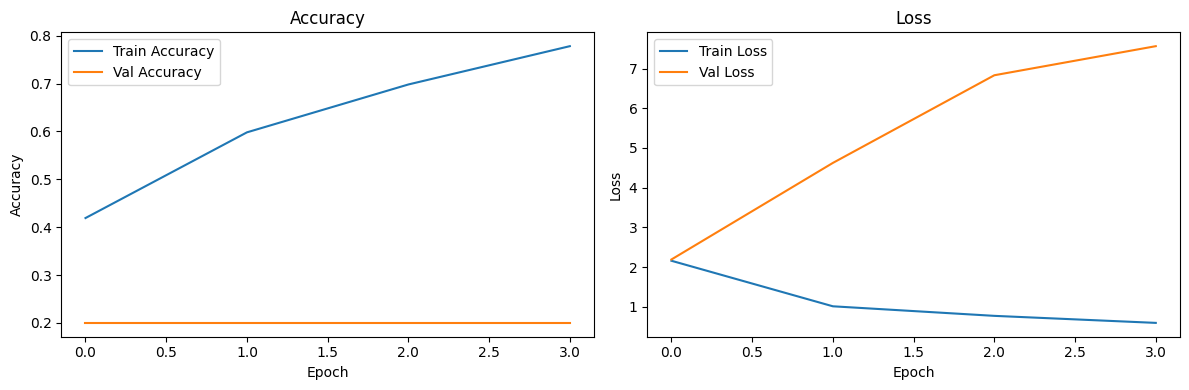

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 387ms/step
               precision    recall  f1-score   support

      01_palm       0.00      0.00      0.00        50
         02_l       0.00      0.00      0.00        50
      03_fist       0.00      0.00      0.00        50
04_fist_moved       0.20      1.00      0.33        50
     05_thumb       0.00      0.00      0.00        50

     accuracy                           0.20       250
    macro avg       0.04      0.20      0.07       250
 weighted avg       0.04      0.20      0.07       250



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


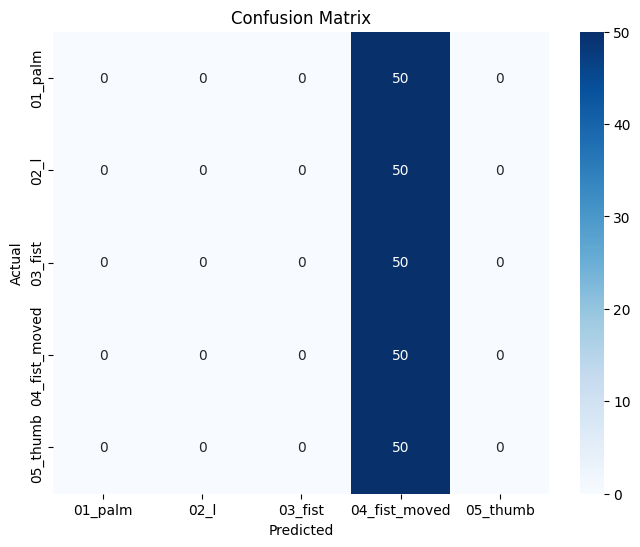

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

val_gen.reset()
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes

class_names = list(val_gen.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [12]:
model.save("/content/hand_gesture_cnn_final.h5")